# 🔍 Job Recommendation System
### NLP-Powered: Extract Skills → Similarity Matching → Recommend

**Dataset:** `all_job_post.csv`  
**Problem:** Given a user's skills, recommend the most relevant job postings using NLP techniques.

---
### Pipeline Overview
```
Raw CSV → EDA → Preprocessing → NLP (TF-IDF / Skill Extraction) → Cosine Similarity → Recommendations
```

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Downloads
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('all_job_post.csv')

print(f"📦 Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"🗂  Columns        : {df.columns.tolist()}")
print(f"🏷  Categories     : {df['category'].unique().tolist()}")
df.head(3)

📦 Dataset Shape  : 1167 rows × 5 columns
🗂  Columns        : ['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']
🏷  Categories     : ['HR', 'INFORMATION-TECHNOLOGY', 'SALES', 'FINANCE', 'BUSINESS-DEVELOPMENT']


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Info & Data Types

In [3]:
print("=" * 50)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("NULL VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Total duplicates: {df.duplicated().sum()}")

DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           1167 non-null   int64
 1   category         1167 non-null   str  
 2   job_title        1167 non-null   str  
 3   job_description  1167 non-null   str  
 4   job_skill_set    1167 non-null   str  
dtypes: int64(1), str(4)
memory usage: 45.7 KB

NULL VALUES PER COLUMN
job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

DUPLICATE ROWS
Total duplicates: 0


### 3.2 Category Distribution

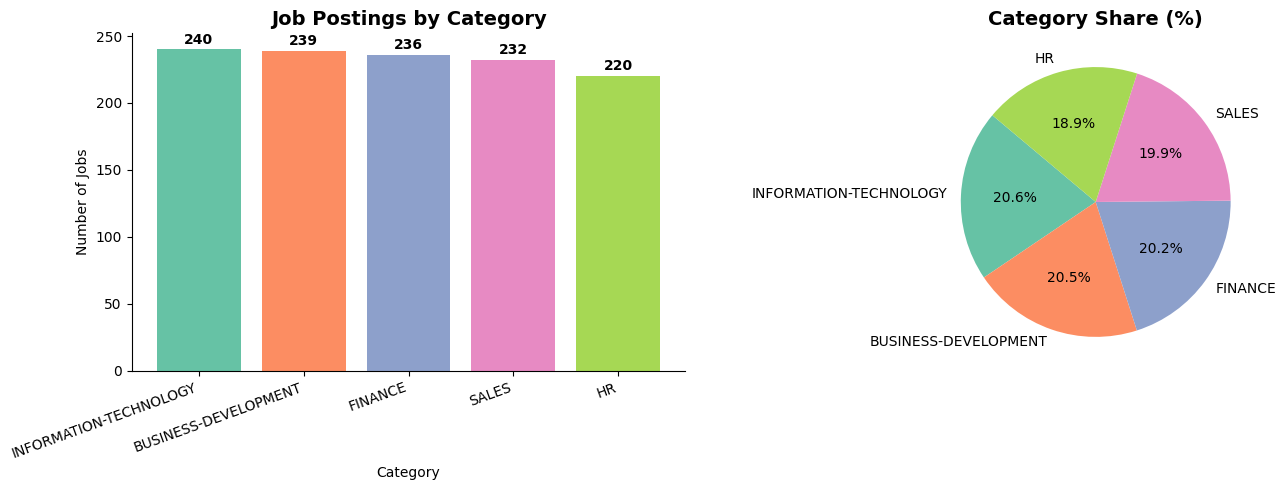

category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64


In [4]:
cat_counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2', len(cat_counts)))
axes[0].set_title('Job Postings by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_xticklabels(cat_counts.index, rotation=20, ha='right')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', len(cat_counts)))
axes[1].set_title('Category Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(cat_counts)

### 3.3 Job Title Analysis

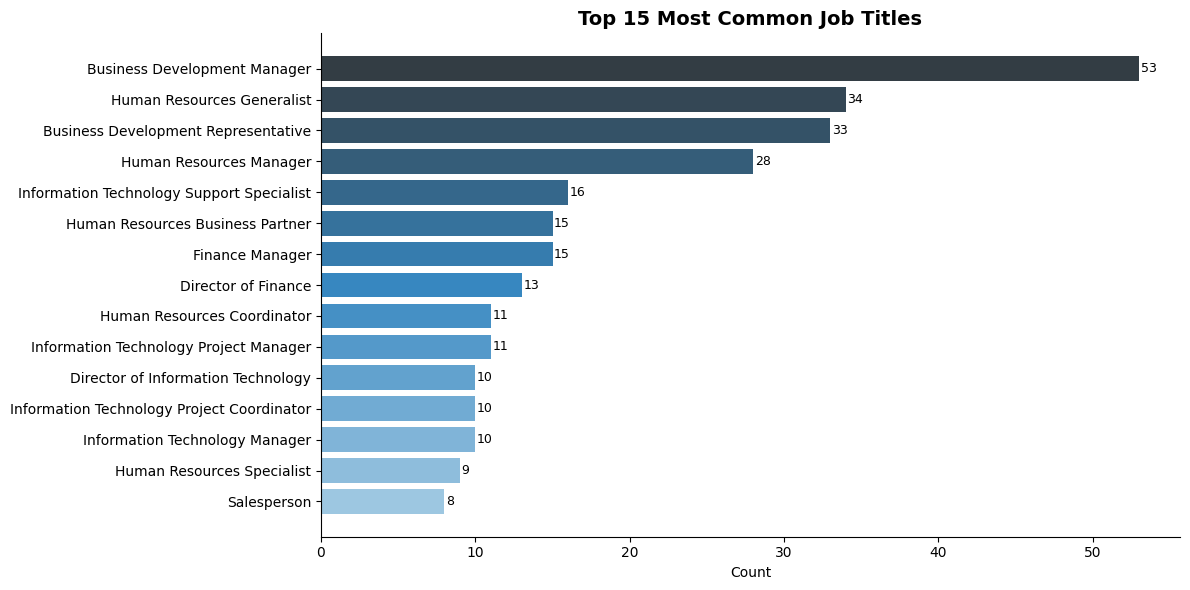

In [5]:
top_titles = df['job_title'].value_counts().head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_titles.index[::-1], top_titles.values[::-1],
                color=sns.color_palette('Blues_d', 15))
plt.title('Top 15 Most Common Job Titles', fontsize=14, fontweight='bold')
plt.xlabel('Count')
for bar, val in zip(bars, top_titles.values[::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_job_titles.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.4 Text Length Analysis

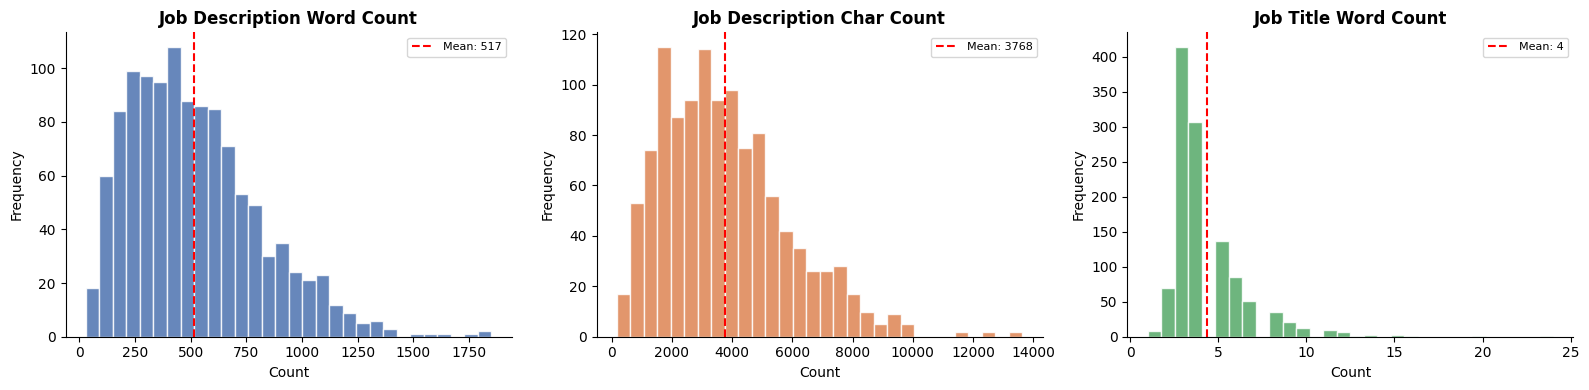

       desc_word_count  desc_char_count  title_word_count
count           1167.0           1167.0            1167.0
mean             516.8           3768.3               4.4
std              293.4           2103.1               2.2
min               29.0            167.0               1.0
25%              287.5           2124.0               3.0
50%              471.0           3445.0               4.0
75%              682.0           4932.5               5.0
max             1851.0          13639.0              24.0


In [6]:
df['desc_word_count']  = df['job_description'].apply(lambda x: len(str(x).split()))
df['desc_char_count']  = df['job_description'].apply(lambda x: len(str(x)))
df['title_word_count'] = df['job_title'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ['desc_word_count', 'desc_char_count', 'title_word_count'],
    ['Job Description Word Count', 'Job Description Char Count', 'Job Title Word Count'],
    ['#4C72B0', '#DD8452', '#55A868']
):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(df[['desc_word_count', 'desc_char_count', 'title_word_count']].describe().round(1))

### 3.5 Skill Set Exploration

📊 Skills per Job Posting:
count    1167.00
mean       17.85
std         4.98
min         5.00
25%        15.00
50%        18.00
75%        20.00
max        43.00
Name: skill_count, dtype: float64


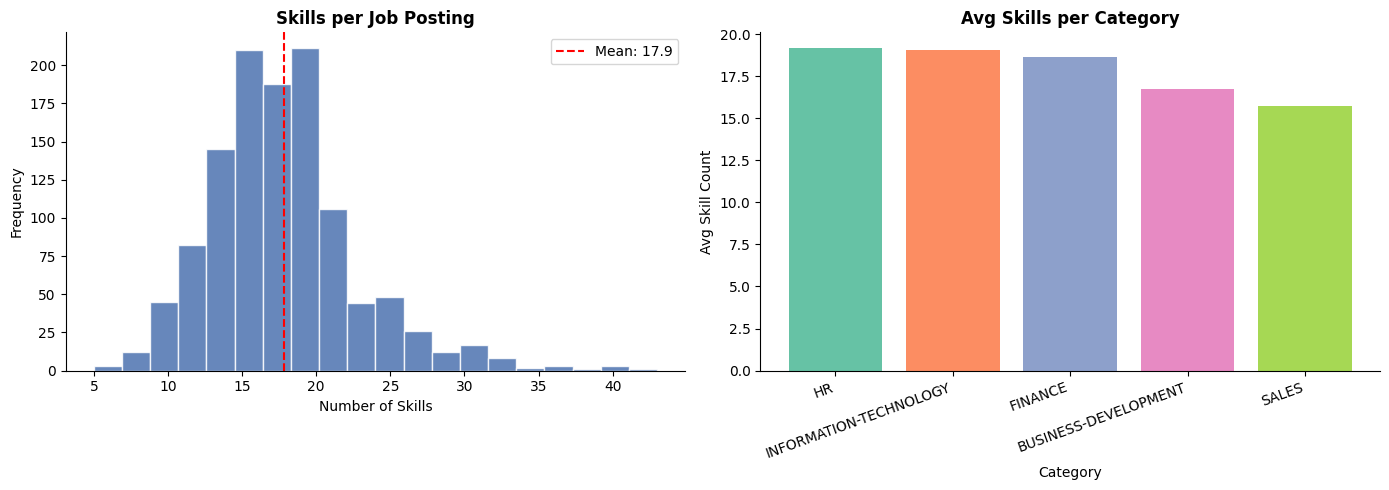

In [7]:
def parse_skills(skill_str):
    """Parse skill list from string representation."""
    try:
        return ast.literal_eval(skill_str)
    except:
        return [s.strip().strip("'[]") for s in str(skill_str).split(',')]

df['skills_list'] = df['job_skill_set'].apply(parse_skills)
df['skill_count']  = df['skills_list'].apply(len)

print("📊 Skills per Job Posting:")
print(df['skill_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skill count distribution
axes[0].hist(df['skill_count'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['skill_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['skill_count'].mean():.1f}")
axes[0].set_title('Skills per Job Posting', fontweight='bold')
axes[0].set_xlabel('Number of Skills')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Avg skill count by category
avg_skills = df.groupby('category')['skill_count'].mean().sort_values(ascending=False)
axes[1].bar(avg_skills.index, avg_skills.values,
            color=sns.color_palette('Set2', len(avg_skills)))
axes[1].set_title('Avg Skills per Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Skill Count')
axes[1].set_xticklabels(avg_skills.index, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('skill_count_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.6 Top Skills by Category

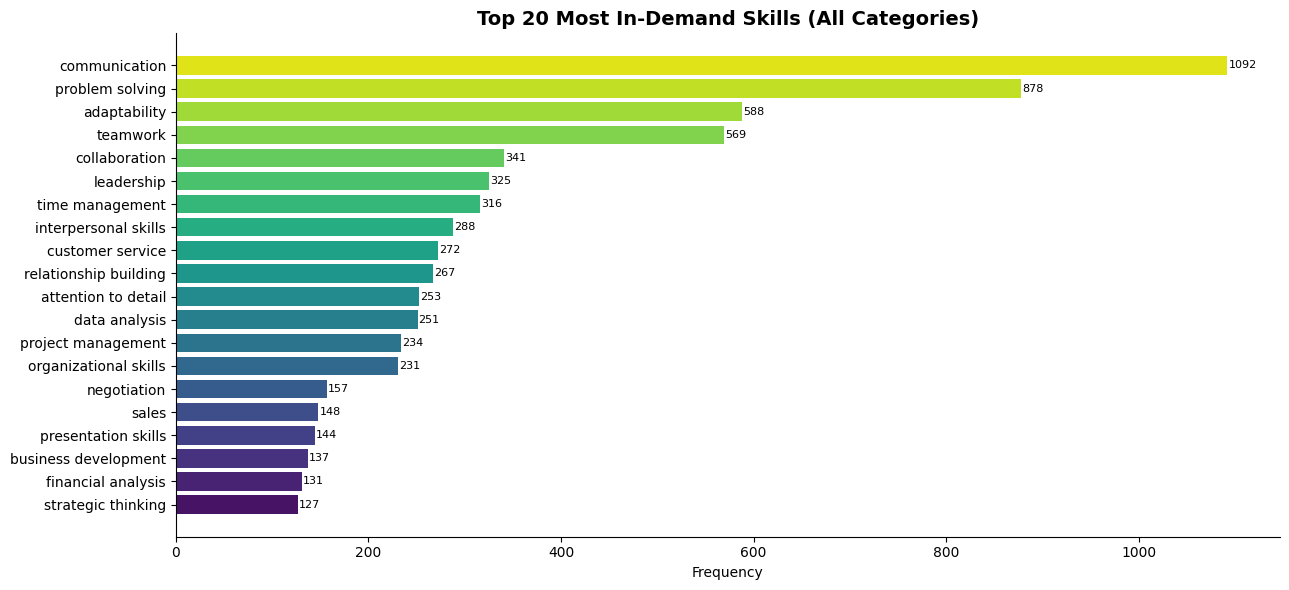

In [8]:
all_skills_flat = [skill.lower().strip() for skills in df['skills_list'] for skill in skills]
top_skills_overall = Counter(all_skills_flat).most_common(20)

skill_names, skill_counts = zip(*top_skills_overall)

plt.figure(figsize=(13, 6))
bars = plt.barh(list(skill_names)[::-1], list(skill_counts)[::-1],
                color=sns.color_palette('viridis', 20))
plt.title('Top 20 Most In-Demand Skills (All Categories)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
for bar, val in zip(bars, list(skill_counts)[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_skills_overall.png', dpi=120, bbox_inches='tight')
plt.show()

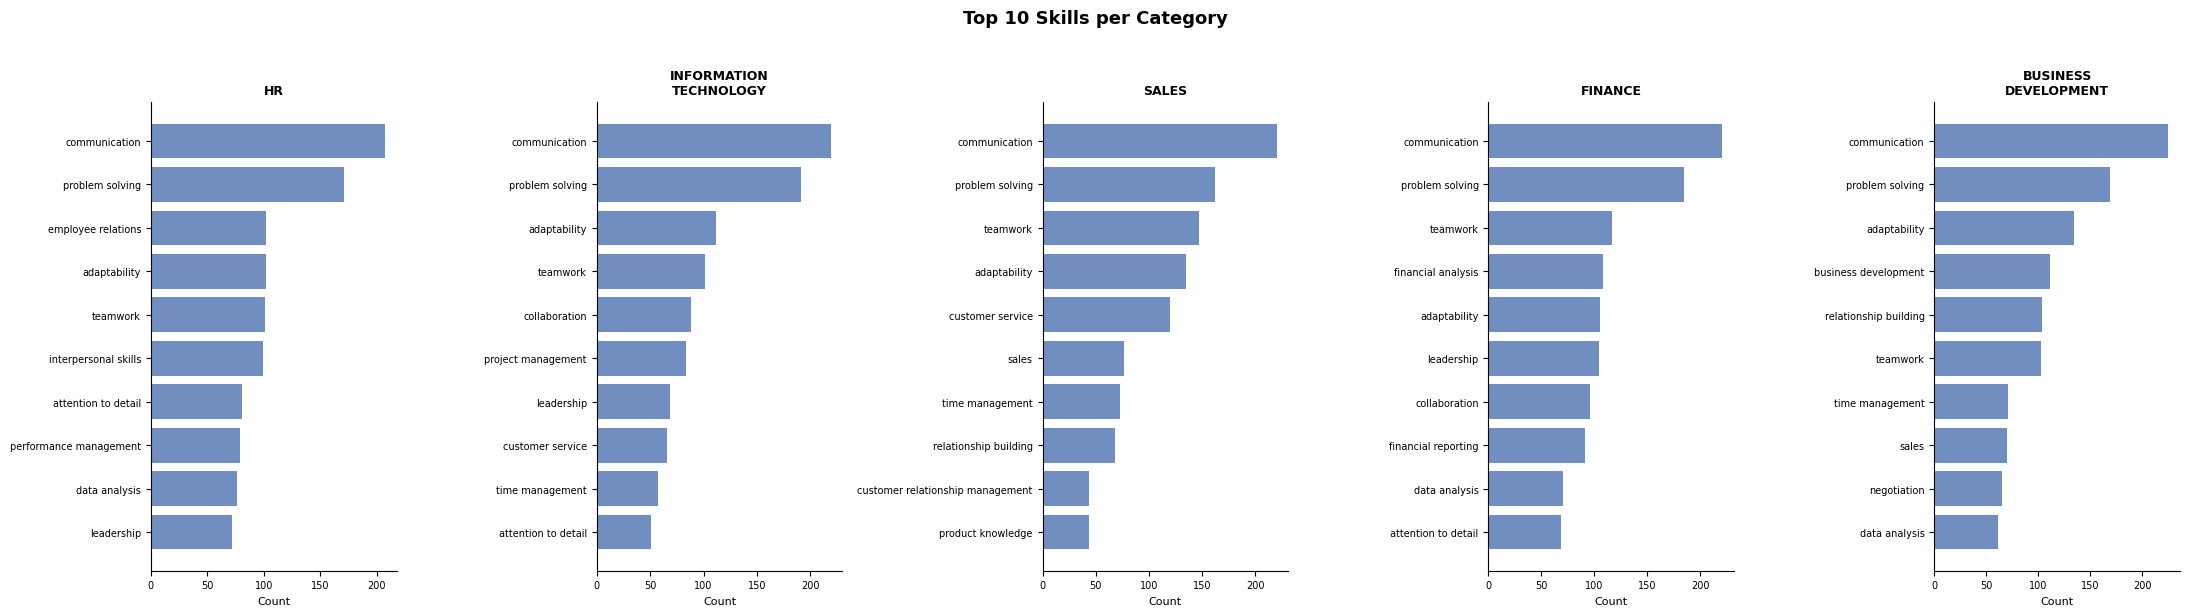

In [9]:
# Top 10 skills per category
categories = df['category'].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(22, 6))

for ax, cat in zip(axes, categories):
    cat_skills = [skill.lower().strip()
                  for skills in df[df['category'] == cat]['skills_list']
                  for skill in skills]
    top = Counter(cat_skills).most_common(10)
    if top:
        names, counts = zip(*top)
        ax.barh(list(names)[::-1], list(counts)[::-1], color='#4C72B0', alpha=0.8)
        ax.set_title(cat.replace('-', '\n'), fontsize=9, fontweight='bold')
        ax.set_xlabel('Count', fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Top 10 Skills per Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('skills_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

### 4.1 Text Cleaning

In [10]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    """Lowercase → remove specials → tokenize → remove stopwords → lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()      # collapse whitespace
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("⚙️  Cleaning job descriptions...")
df['clean_description'] = df['job_description'].apply(clean_text)
print("⚙️  Cleaning job titles...")
df['clean_title'] = df['job_title'].apply(clean_text)

print("\n✅ Cleaning complete!")
print("\nSample — Original title:")
print(df['job_title'].iloc[0])
print("\nSample — Cleaned title:")
print(df['clean_title'].iloc[0])
print("\nSample — Cleaned description (first 300 chars):")
print(df['clean_description'].iloc[0][:300])

⚙️  Cleaning job descriptions...


⚙️  Cleaning job titles...

✅ Cleaning complete!

Sample — Original title:
Sr Human Resource Generalist

Sample — Cleaned title:
human resource generalist

Sample — Cleaned description (first 300 chars):
summary generalist provides expertise across various function including employee relation talent acquisition performance management payroll compensation benefit generalist responsibility strategic administrative consultative role provides consultative business partner support assigned business unit 


### 4.2 Skill String Preprocessing

In [11]:
def skills_to_string(skills_list):
    """Join parsed skills into a clean, lowercase string for vectorization."""
    cleaned = [re.sub(r'[^a-z\s]', '', s.lower().strip()) for s in skills_list]
    return ' '.join([c for c in cleaned if c.strip()])

df['skills_string'] = df['skills_list'].apply(skills_to_string)

print("Sample skills string:")
print(df['skills_string'].iloc[0])

Sample skills string:
employee relations talent acquisition performance management compensation and benefits employment laws and regulations analytical skills employee benefits administration hr policies and procedures recruitment strategies fmla ada communication interpersonal skills collaboration influence change management professional development payroll processing job design salary administration human capital management system hr audits and assessments flsa erisa eeoc guidelines confidentiality intellectual curiosity


### 4.3 Combined Feature for NLP

In [12]:
# Weighted combination: skills × 3 (highest signal) + title × 2 + description × 1
df['combined_features'] = (
    df['skills_string'] + ' ' + df['skills_string'] + ' ' + df['skills_string'] + ' ' +
    df['clean_title']   + ' ' + df['clean_title']   + ' ' +
    df['clean_description']
)

print(f"✅ Combined feature column created.")
print(f"   Avg length: {df['combined_features'].apply(len).mean():.0f} chars")
df[['job_title', 'category', 'combined_features']].head(3)

✅ Combined feature column created.
   Avg length: 3881 chars


,job_title,category,combined_features
0,Sr Human Resource Generalist,HR,employee relations talent acquisition performa...
1,Human Resources Manager,HR,talent acquisition employee performance manage...
2,Director of Human Resources,HR,human resources management recruitment employe...


### 4.4 Label Encode Category

In [13]:
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Category → Encoded label mapping:")
for k, v in mapping.items():
    print(f"  {k:30s} → {v}")

Category → Encoded label mapping:
  BUSINESS-DEVELOPMENT           → 0
  FINANCE                        → 1
  HR                             → 2
  INFORMATION-TECHNOLOGY         → 3
  SALES                          → 4


## 5. NLP — TF-IDF Vectorization

In [14]:
# TF-IDF on combined features
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=2,                  # ignore very rare terms
    max_df=0.85,               # ignore very common terms
    sublinear_tf=True          # log-scale TF
)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print(f"✅ TF-IDF Matrix Shape : {tfidf_matrix.shape}")
print(f"   Rows  = job postings : {tfidf_matrix.shape[0]}")
print(f"   Cols  = vocabulary   : {tfidf_matrix.shape[1]}")
print(f"   Sparsity             : {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}")

# Show top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
sample_row    = tfidf_matrix[0].toarray().flatten()
top_indices   = sample_row.argsort()[-10:][::-1]

print(f"\n🔑 Top 10 TF-IDF terms for job: '{df['job_title'].iloc[0]}'")
for idx in top_indices:
    print(f"   {feature_names[idx]:30s}  score: {sample_row[idx]:.4f}")

✅ TF-IDF Matrix Shape : (1167, 5000)
   Rows  = job postings : 1167
   Cols  = vocabulary   : 5000
   Sparsity             : 94.49%

🔑 Top 10 TF-IDF terms for job: 'Sr Human Resource Generalist'
   erisa                           score: 0.1331
   payroll processing              score: 0.1293
   intellectual curiosity          score: 0.1289
   fmla ada                        score: 0.1289
   capital management              score: 0.1270
   flsa                            score: 0.1237
   and regulations                 score: 0.1192
   eeoc                            score: 0.1183
   human capital                   score: 0.1183
   intellectual                    score: 0.1171


### 5.1 Skills-Only TF-IDF (for skill-based matching)

In [15]:
skill_tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

skill_matrix = skill_tfidf.fit_transform(df['skills_string'])

print(f"✅ Skills TF-IDF Matrix Shape: {skill_matrix.shape}")
print(f"   Vocabulary size: {len(skill_tfidf.get_feature_names_out())}")

✅ Skills TF-IDF Matrix Shape: (1167, 2000)
   Vocabulary size: 2000


## 6. Similarity Matching

In [16]:
# Pre-compute cosine similarity matrix (for quick lookup)
# NOTE: For large datasets, we compute on-demand per query instead
print("Computing cosine similarity matrix (job-to-job)...")
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"✅ Similarity matrix shape: {cosine_sim_matrix.shape}")
print(f"   Min similarity: {cosine_sim_matrix.min():.4f}")
print(f"   Max similarity (excl. diagonal): {np.sort(cosine_sim_matrix, axis=1)[:, -2].mean():.4f} (avg 2nd highest)")

Computing cosine similarity matrix (job-to-job)...
✅ Similarity matrix shape: (1167, 1167)


   Min similarity: 0.0000
   Max similarity (excl. diagonal): 0.3515 (avg 2nd highest)


### 6.1 Visualise Similarity Heatmap (sample)

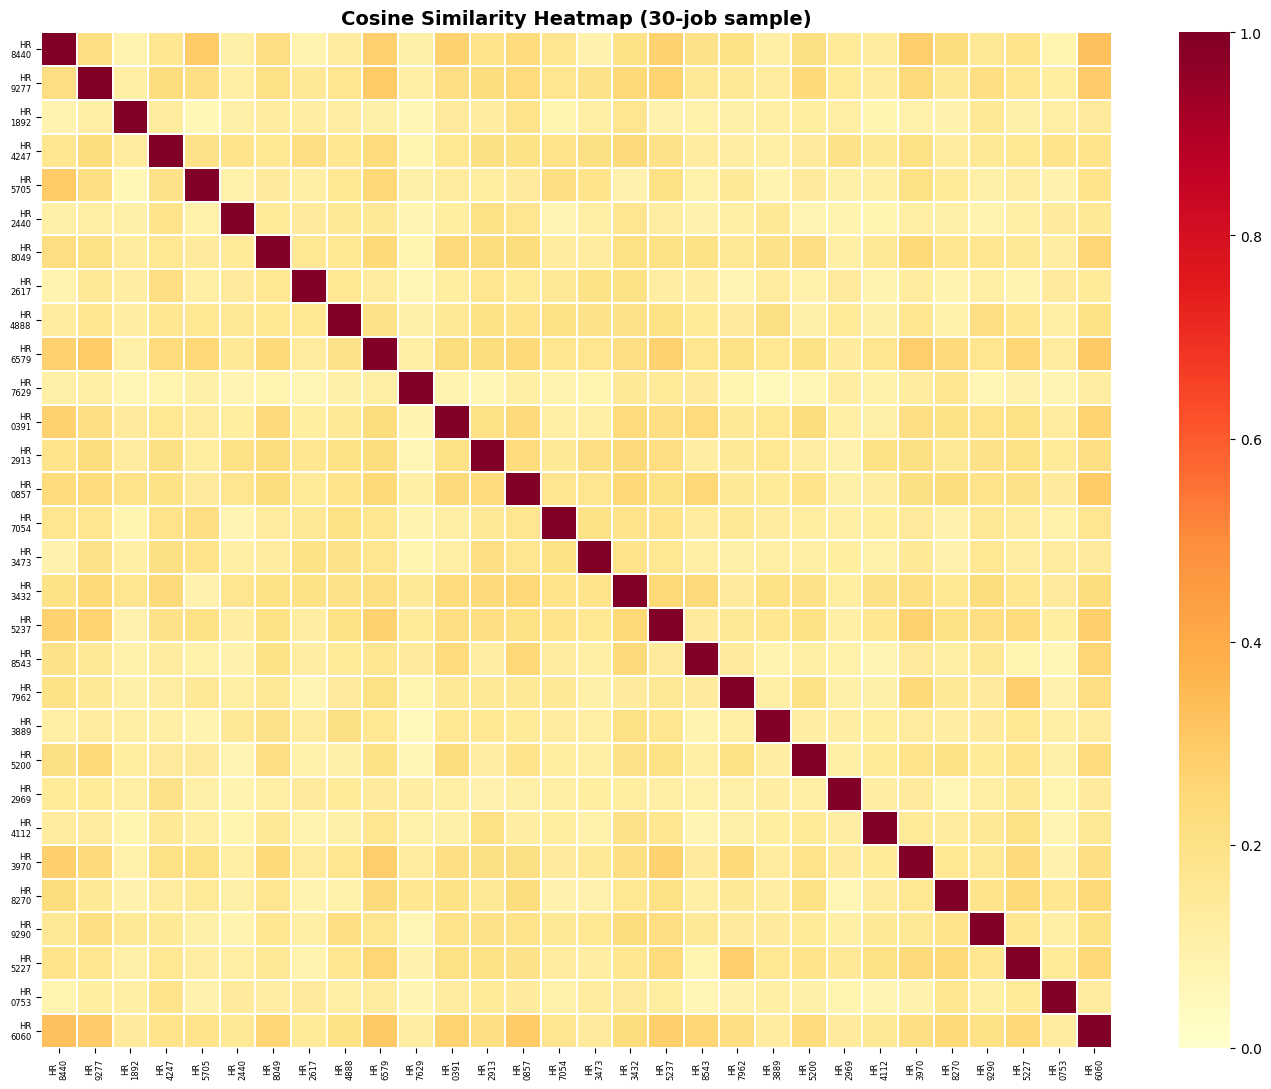

In [17]:
# Sample 30 jobs for a readable heatmap
sample_idx = list(range(0, 150, 5))   # every 5th from first 150
sim_sample  = cosine_sim_matrix[np.ix_(sample_idx, sample_idx)]
labels      = [f"{df['category'].iloc[i][:4]}\n{str(df['job_id'].iloc[i])[-4:]}" for i in sample_idx]

plt.figure(figsize=(14, 11))
sns.heatmap(sim_sample, xticklabels=labels, yticklabels=labels,
            cmap='YlOrRd', linewidths=0.3, annot=False, vmin=0, vmax=1)
plt.title('Cosine Similarity Heatmap (30-job sample)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Job Recommendation System

In [18]:
def extract_user_skills(raw_input):
    """
    Clean and preprocess user-provided skills.
    Input  : comma-separated string  e.g. 'Python, Machine Learning, SQL'
    Output : cleaned string for TF-IDF vectorization
    """
    skills = [s.strip().lower() for s in raw_input.split(',') if s.strip()]
    cleaned = [re.sub(r'[^a-z\s]', '', s) for s in skills]
    return ' '.join(cleaned)


def recommend_jobs(user_skills_raw,
                   top_n=5,
                   filter_category=None,
                   vectorizer=tfidf,
                   job_matrix=tfidf_matrix,
                   df=df):
    """
    Recommend top-N jobs based on user skills.

    Parameters
    ----------
    user_skills_raw  : str   Comma-separated skills string
    top_n            : int   Number of recommendations to return
    filter_category  : str   Optional category filter (e.g. 'HR')
    vectorizer       : fitted TfidfVectorizer
    job_matrix       : pre-computed TF-IDF matrix for all jobs
    df               : DataFrame with job postings

    Returns
    -------
    DataFrame with recommended jobs and similarity scores
    """
    if not user_skills_raw.strip():
        print("❌ Please provide at least one skill.")
        return None

    # Step 1 — Extract & clean user skills
    user_vector_str = extract_user_skills(user_skills_raw)
    print(f"🔍 Processed skills query: '{user_vector_str}'")

    # Step 2 — Vectorize user query
    user_vec = vectorizer.transform([user_vector_str])

    # Step 3 — Compute cosine similarity
    if filter_category:
        mask       = (df['category'].str.upper() == filter_category.upper()).values
        indices    = np.where(mask)[0]
        sub_matrix = job_matrix[indices]
        sub_df     = df.iloc[indices].reset_index(drop=True)
    else:
        sub_matrix = job_matrix
        sub_df     = df.reset_index(drop=True)

    similarities = cosine_similarity(user_vec, sub_matrix).flatten()

    # Step 4 — Rank and return top N
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = sub_df.iloc[top_indices][['job_id', 'category', 'job_title', 'skills_list']].copy()
    results['similarity_score'] = similarities[top_indices].round(4)
    results['match_pct']        = (results['similarity_score'] * 100).round(1).astype(str) + '%'
    results = results.reset_index(drop=True)
    results.index += 1   # rank from 1

    return results


print("✅ Recommendation functions defined!")

✅ Recommendation functions defined!


### 7.1 Test — IT / Developer Skills

In [19]:
user_skills_it = "Python, machine learning, SQL, data analysis, deep learning, TensorFlow, NLP"

print("=" * 60)
print("👤 USER SKILLS:")
print(f"   {user_skills_it}")
print("=" * 60)

recs_it = recommend_jobs(user_skills_it, top_n=5)
print()
print(recs_it[['job_id', 'category', 'job_title', 'match_pct']].to_string())

👤 USER SKILLS:
   Python, machine learning, SQL, data analysis, deep learning, TensorFlow, NLP
🔍 Processed skills query: 'python machine learning sql data analysis deep learning tensorflow nlp'

       job_id                category                                                                 job_title match_pct
1  3901998589                 FINANCE  VP / Client, Finance & Strategy Data Scientist Lead – JPM Private Client     26.3%
2  3906246896                 FINANCE                                 Lead Software Engineer - Finance (Hybrid)     26.2%
3  3903458683  INFORMATION-TECHNOLOGY                                         Information Technology Specialist     21.7%
4  3895527225                 FINANCE          Data Solutions Analyst II (Managed Care - Finance Focus) - R7269     20.4%
5  3901649881    BUSINESS-DEVELOPMENT                       Enterprise Business Development Representative - US     19.4%


### 7.2 Test — HR Skills

In [20]:
user_skills_hr = "talent acquisition, employee relations, performance management, payroll, SHRM, compliance"

print("=" * 60)
print("👤 USER SKILLS:")
print(f"   {user_skills_hr}")
print("=" * 60)

recs_hr = recommend_jobs(user_skills_hr, top_n=5)
print()
print(recs_hr[['job_id', 'category', 'job_title', 'match_pct']].to_string())

👤 USER SKILLS:
   talent acquisition, employee relations, performance management, payroll, SHRM, compliance
🔍 Processed skills query: 'talent acquisition employee relations performance management payroll shrm compliance'

       job_id category                      job_title match_pct
1  3905882432       HR       Human Resources Director     28.6%
2  3904973138       HR        Human Resources Manager     27.5%
3  3905823748       HR        Human Resources Manager     23.8%
4  3902933509       HR  Plant Human Resources Manager     22.1%
5  3887481930       HR    Director of Human Resources     21.5%


### 7.3 Test — Finance Skills with Category Filter

In [21]:
user_skills_fin = "financial analysis, budgeting, forecasting, Excel, risk management, CPA, accounting"

print("=" * 60)
print("👤 USER SKILLS (filtered to FINANCE only):")
print(f"   {user_skills_fin}")
print("=" * 60)

recs_fin = recommend_jobs(user_skills_fin, top_n=5, filter_category='FINANCE')
print()
print(recs_fin[['job_id', 'category', 'job_title', 'match_pct']].to_string())

👤 USER SKILLS (filtered to FINANCE only):
   financial analysis, budgeting, forecasting, Excel, risk management, CPA, accounting
🔍 Processed skills query: 'financial analysis budgeting forecasting excel risk management cpa accounting'

       job_id category                                                                 job_title match_pct
1  3905843981  FINANCE                                                    Senior Finance Manager     29.6%
2  3905293915  FINANCE                                                  Finance Business Partner     28.4%
3  3889113843  FINANCE  Early Careers: Accounting/Finance - Internship Summer 2024 -Philadelphia     25.4%
4  3895222638  FINANCE                                                    Vice President Finance     25.4%
5  3885112179  FINANCE                                        Director of Finance And Accounting     25.1%


### 7.4 Visualise Recommendation Scores

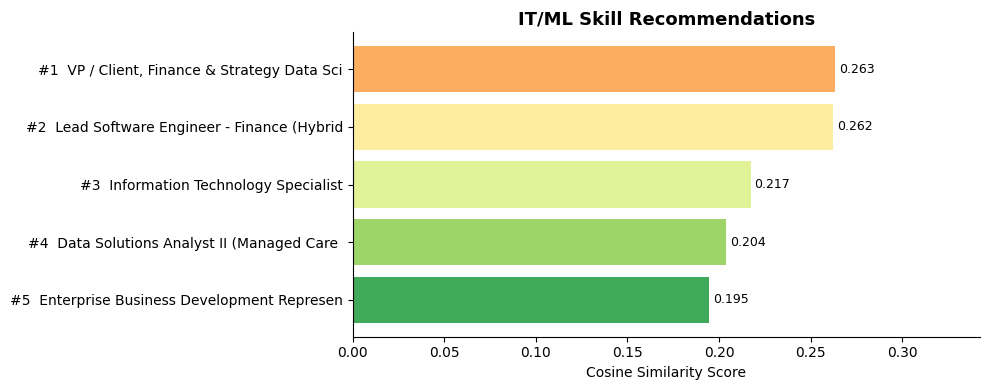

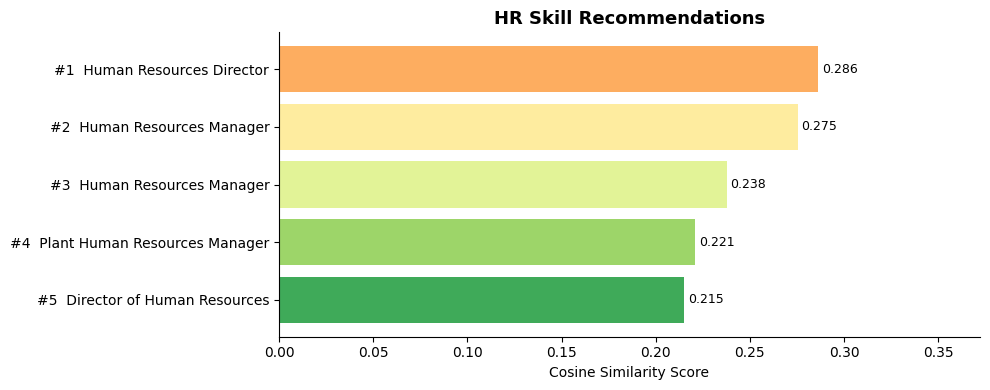

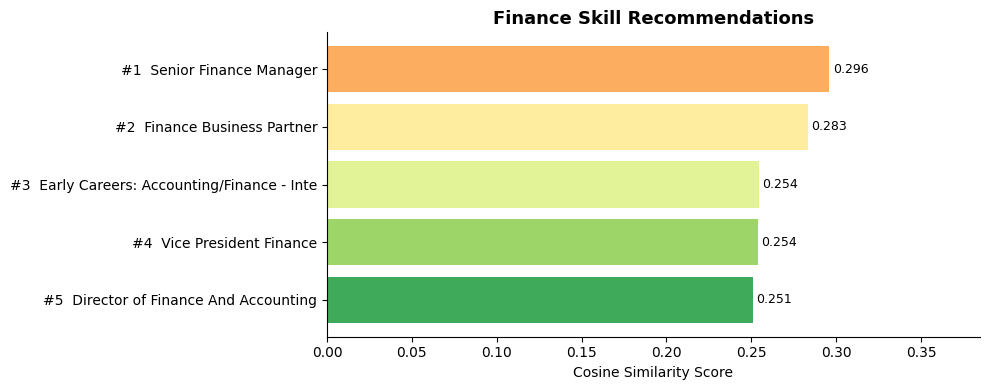

In [22]:
def plot_recommendations(recs, title='Job Recommendations'):
    """Bar chart of recommended jobs with similarity scores."""
    fig, ax = plt.subplots(figsize=(10, 4))

    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(recs)))
    labels = [f"#{i}  {row['job_title'][:40]}" for i, row in recs.iterrows()]

    bars = ax.barh(labels[::-1], recs['similarity_score'][::-1], color=colors[::-1])
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, min(recs['similarity_score'].max() * 1.3, 1.0))

    for bar, val in zip(bars, recs['similarity_score'][::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'recommendations_{title[:15].replace(" ","_").replace("/","-")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_recommendations(recs_it,  'IT/ML Skill Recommendations')
plot_recommendations(recs_hr,  'HR Skill Recommendations')
plot_recommendations(recs_fin, 'Finance Skill Recommendations')

## 8. Skill Gap Analysis

In [23]:
def skill_gap_analysis(user_skills_raw, job_row):
    """
    Compare user's skills against a recommended job's required skills.
    Returns matched skills, missing skills, and match percentage.
    """
    user_skills_set = set([s.strip().lower() for s in user_skills_raw.split(',')])
    job_skills_set  = set([s.strip().lower() for s in job_row['skills_list']])

    matched  = user_skills_set & job_skills_set
    missing  = job_skills_set  - user_skills_set
    extra    = user_skills_set - job_skills_set
    match_pct = len(matched) / len(job_skills_set) * 100 if job_skills_set else 0

    return {
        'job_title'    : job_row['job_title'],
        'category'     : job_row['category'],
        'matched'      : sorted(matched),
        'missing'      : sorted(missing),
        'extra'        : sorted(extra),
        'match_pct'    : round(match_pct, 1)
    }


# Run gap analysis on top IT recommendation
top_job_row = df[df['job_id'] == recs_it.iloc[0]['job_id']].iloc[0]
gap         = skill_gap_analysis(user_skills_it, top_job_row)

print("=" * 60)
print(f"📋 SKILL GAP ANALYSIS")
print(f"   Job     : {gap['job_title']}")
print(f"   Category: {gap['category']}")
print(f"   Match   : {gap['match_pct']}%")
print("=" * 60)
print(f"\n✅ Matched skills ({len(gap['matched'])})  : {gap['matched']}")
print(f"\n❌ Missing skills ({len(gap['missing'])}) : {gap['missing']}")
print(f"\n➕ Extra skills   ({len(gap['extra'])})   : {gap['extra']}")

📋 SKILL GAP ANALYSIS
   Job     : VP / Client, Finance & Strategy Data Scientist Lead – JPM Private Client
   Category: FINANCE
   Match   : 9.7%

✅ Matched skills (3)  : ['machine learning', 'python', 'sql']

❌ Missing skills (28) : ['apache spark', 'aws', 'big data', 'business acumen', 'causal-model approaches', 'cloud platforms', 'communication', 'data integrity', 'data mining', 'data preparation', 'data visualization', 'hadoop', 'hive', 'iterative development', 'pig', 'predictive modeling', 'problem solving', 'project management', 'regressions', 'stakeholder engagement', 'statistical software', 'storytelling', 'strategic thinking', 'tableau', 'teamwork', 'text mining', 'time series analysis', 'transparency']

➕ Extra skills   (4)   : ['data analysis', 'deep learning', 'nlp', 'tensorflow']


### 8.1 Skill Gap Visualisation

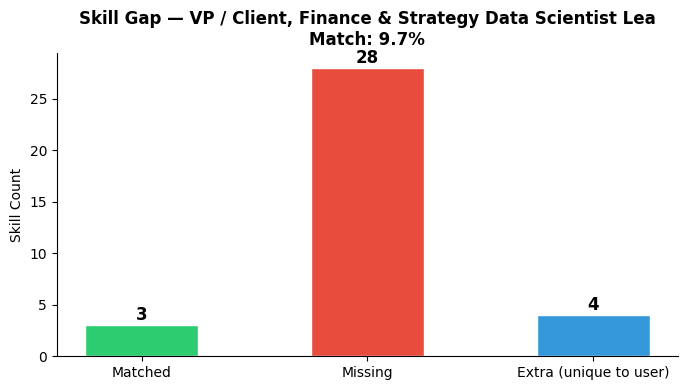

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))

categories_gap = ['Matched', 'Missing', 'Extra (unique to user)']
counts_gap     = [len(gap['matched']), len(gap['missing']), len(gap['extra'])]
colors_gap     = ['#2ecc71', '#e74c3c', '#3498db']

bars = ax.bar(categories_gap, counts_gap, color=colors_gap, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts_gap):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title(f"Skill Gap — {gap['job_title'][:50]}\nMatch: {gap['match_pct']}%",
             fontsize=12, fontweight='bold')
ax.set_ylabel('Skill Count')
plt.tight_layout()
plt.savefig('skill_gap.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. NLP Analysis — Word Frequency & N-grams

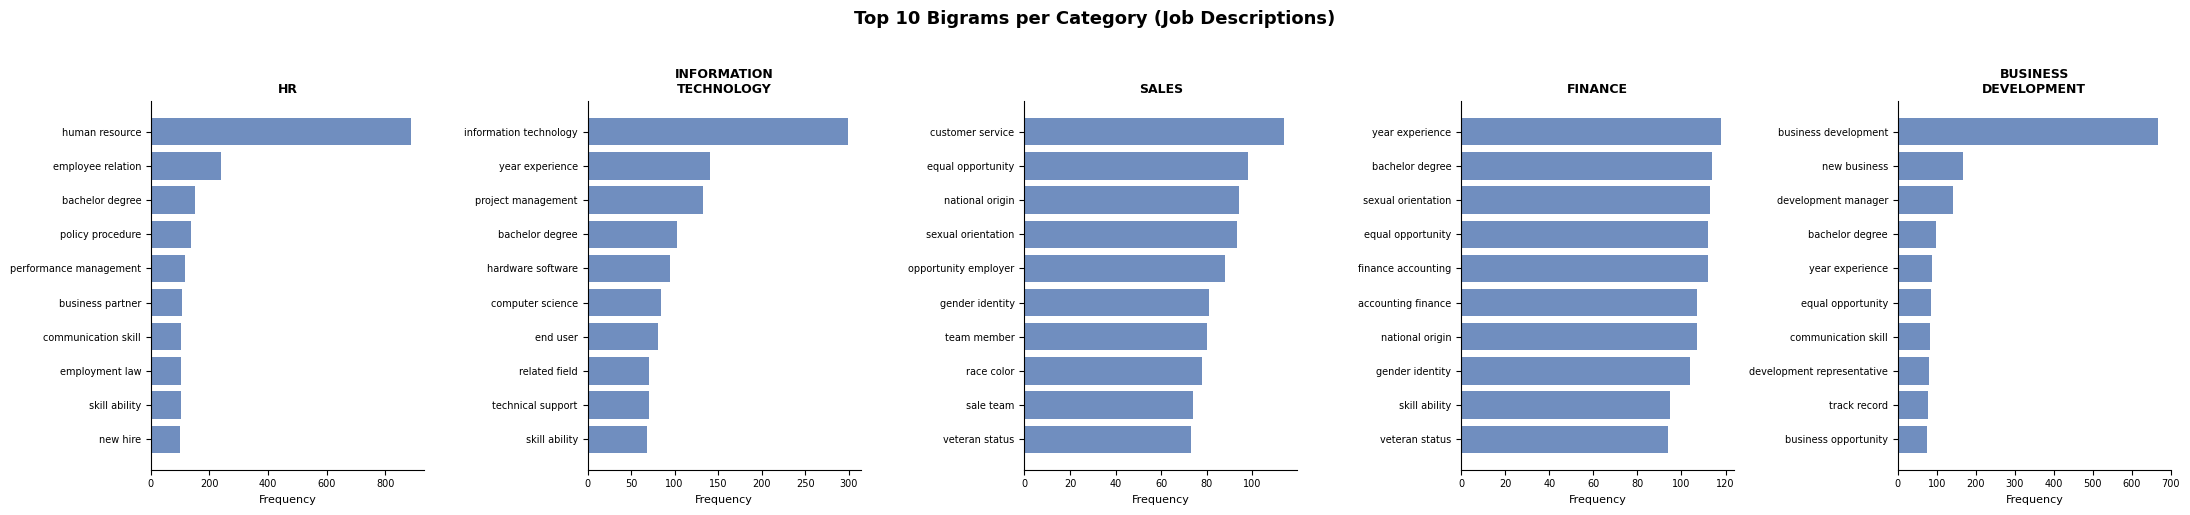

In [25]:
# Top bigrams from job descriptions per category
def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=500)
    X   = vec.fit_transform(corpus)
    freqs = X.toarray().sum(axis=0)
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, freqs), key=lambda x: -x[1])[:top_k]

fig, axes = plt.subplots(1, len(categories), figsize=(22, 5))

for ax, cat in zip(axes, categories):
    corpus = df[df['category'] == cat]['clean_description'].tolist()
    bigrams = get_top_ngrams(corpus, n=2, top_k=10)
    if bigrams:
        bg_names, bg_counts = zip(*bigrams)
        ax.barh(list(bg_names)[::-1], list(bg_counts)[::-1],
                color='#4C72B0', alpha=0.8)
        ax.set_title(cat.replace('-', '\n'), fontsize=9, fontweight='bold')
        ax.set_xlabel('Frequency', fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Top 10 Bigrams per Category (Job Descriptions)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bigrams_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Final Clean Dataset Export

In [26]:
output_cols = [
    'job_id', 'category', 'category_encoded',
    'job_title', 'clean_title',
    'job_description', 'clean_description',
    'skills_list', 'skills_string', 'skill_count',
    'combined_features',
    'desc_word_count', 'desc_char_count', 'title_word_count'
]

df_clean = df[output_cols].copy()
df_clean.to_csv('all_job_post_cleaned.csv', index=False)

print("✅ Cleaned dataset exported → all_job_post_cleaned.csv")
print(f"   Shape: {df_clean.shape}")
df_clean.head(3)

✅ Cleaned dataset exported → all_job_post_cleaned.csv
   Shape: (1167, 14)


,job_id,category,category_encoded,job_title,clean_title,job_description,clean_description,skills_list,skills_string,skill_count,combined_features,desc_word_count,desc_char_count,title_word_count
0,3902668440,HR,2,Sr Human Resource Generalist,human resource generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,summary generalist provides expertise across v...,"[employee relations, talent acquisition, perfo...",employee relations talent acquisition performa...,27,employee relations talent acquisition performa...,583,4397,4
1,3905823748,HR,2,Human Resources Manager,human resource manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,part stellar team ysb manager human resource j...,"[Talent Acquisition, Employee Performance Mana...",talent acquisition employee performance manage...,16,talent acquisition employee performance manage...,323,2529,3
2,3905854799,HR,2,Director of Human Resources,director human resource,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,client thriving organization offering unique o...,"[Human Resources Management, Recruitment, Empl...",human resources management recruitment employe...,20,human resources management recruitment employe...,666,4910,4


## 11. Summary

In [27]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         JOB RECOMMENDATION SYSTEM — SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset     : 1,167 jobs  ×  5 categories                  ║
║  Preprocessing:                                              ║
║    • Lowercasing, special char removal, tokenization         ║
║    • Stopword removal, lemmatization (NLTK)                  ║
║    • Skill parsing + skill string construction               ║
║    • Weighted combined feature (skills×3 + title×2 + desc)  ║
║  NLP Model   : TF-IDF (5,000 features, bigrams, sublinear)  ║
║  Similarity  : Cosine Similarity                             ║
║  Features    :                                               ║
║    ✅ Top-N job recommendations from user skills             ║
║    ✅ Category filter support                                ║
║    ✅ Skill gap analysis (matched / missing / extra)         ║
║    ✅ EDA visualisations (8 plots)                           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         JOB RECOMMENDATION SYSTEM — SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset     : 1,167 jobs  ×  5 categories                  ║
║  Preprocessing:                                              ║
║    • Lowercasing, special char removal, tokenization         ║
║    • Stopword removal, lemmatization (NLTK)                  ║
║    • Skill parsing + skill string construction               ║
║    • Weighted combined feature (skills×3 + title×2 + desc)  ║
║  NLP Model   : TF-IDF (5,000 features, bigrams, sublinear)  ║
║  Similarity  : Cosine Similarity                             ║
║  Features    :                                               ║
║    ✅ Top-N job recommendations from user skills             ║
║    ✅ Category filter support                                ║
║    ✅ Skill gap analysis (matched / missing / extra)         ║
║    ✅ EDA visualisations (8 pl